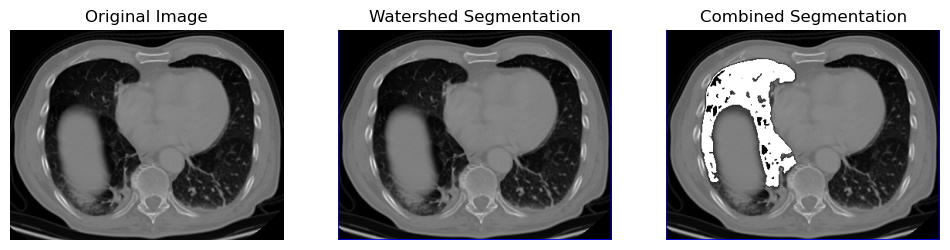

Combined segmentation completed. Check the output image.


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(image, seed_point, threshold):
    # Create an empty mask to keep track of the segmented region
    mask = np.zeros_like(image, dtype=np.uint8)

    # Initialize the list of pixels to process
    to_process = [seed_point]
    region_mean = image[seed_point]

    while to_process:
        # Pop the last pixel from the list
        current_pixel = to_process.pop()

        # If the pixel is already in the mask, skip it
        if mask[current_pixel]:
            continue

        # Add the pixel to the mask
        mask[current_pixel] = 255
        
        # Check neighboring pixels
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # 4-connectivity
            neighbor = (current_pixel[0] + dx, current_pixel[1] + dy)
            if (0 <= neighbor[0] < image.shape[0] and
                0 <= neighbor[1] < image.shape[1] and
                not mask[neighbor] and
                abs(int(image[neighbor]) - int(region_mean)) < threshold):
                
                to_process.append(neighbor)

        # Update the region mean
        region_mean = np.mean(image[mask == 255])

    return mask


def watershed_segmentation(image):
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Perform edge detection using Canny
    edges = cv2.Canny(blurred, 50, 150)

    # Dilate the edges to close gaps
    dilated_edges = cv2.dilate(edges, None, iterations=2)

    # Find contours in the dilated edges
    contours, _ = cv2.findContours(dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a mask for the sure foreground area
    mask = np.zeros(gray.shape, dtype=np.uint8)

    # Fill the contours on the mask
    for contour in contours:
        cv2.drawContours(mask, [contour], -1, 255, -1)

    # Perform distance transform
    dist_transform = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

    # Find unknown region (background)
    unknown = cv2.subtract(mask, sure_fg.astype(np.uint8))

    # Label markers for watershed
    markers = np.zeros_like(gray, dtype=np.int32)
    markers[sure_fg.astype(np.uint8) == 255] = 1
    markers[unknown == 255] = 2

    # Apply the Watershed algorithm
    cv2.watershed(image, markers)

    # Mark the boundaries on the original image
    image[markers == -1] = [255, 0, 0]  # Mark edges in red
    
    return image, markers  # Return both the modified image and the watershed markers


# Load the CT scan image
image_path = '000122.png'  # Ensure the image path is correct
image = cv2.imread(image_path)

# Check if image is loaded correctly
if image is None:
    print("Error: Image not found at", image_path)
    exit()

# Perform Watershed Segmentation
watershed_image, watershed_markers = watershed_segmentation(image.copy())

# Convert the image to grayscale for region growing
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise for region growing
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Set seed point and threshold for region growing
seed_point = (100, 100)  # Adjust based on your image
threshold = 15  # Adjust based on your needs

# Perform Region Growing Segmentation
segmented_mask = region_growing(blurred_image, seed_point, threshold)

# Combine the two segmentation results for visualization
combined_image = cv2.bitwise_or(watershed_image, cv2.cvtColor(segmented_mask, cv2.COLOR_GRAY2BGR))

# Display the results
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Watershed Segmentation Output
plt.subplot(1, 3, 2)
plt.title('Watershed Segmentation')
plt.imshow(cv2.cvtColor(watershed_image, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Combined Segmentation Output
plt.subplot(1, 3, 3)
plt.title('Combined Segmentation')
plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

# Save the result (optional)
output_path = 'combined_segmentation_output.png'  # Path to save the combined output
cv2.imwrite(output_path, combined_image)

print("Combined segmentation completed. Check the output image.")
